In [1]:
import sys
sys.path.append("../")

import math 

import pickle 
import numpy as np 
import torch 
import torch.nn as nn 
import torch.optim as optim 
import torch.nn.functional as F 
from torch.nn.utils import clip_grad_norm_

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from vi_rnn.utils import *
from vi_rnn.load_data import * 
from vi_rnn.saving import load_model

from sklearn.metrics import r2_score

torch.autograd.set_detect_anomaly(True)

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

In [3]:
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

## Load data

In [53]:
config = {
    'data_dir': '../data/recordings/nk339_mPFC/', 
    'dales_law': True,
    'out_dir': "../models/all/",
    'sampling_rate': 30_000,
    'bin_size': 0.05,
    'fr_threshold': 0.5,
    'threshold_neurons': True,
    'z_score_neuromod': False,
    'z_score_neurons': False,
    'deconvolve': False,
    'convolve_spikes': True,
    'normalize_neuromod': True,
    'center_neuromod': False,
    'load_physiology': False,
    'shuffle': False
}

spikes, spike_counts, neuromod_activity, trials_df, cell_types = load_data(config)
# split dataset into train and test samples based on amount of data available 
data_dur = spike_counts.shape[1] * config['bin_size']
# first find when the last trial is. Last trials is always odor, which lasts 120 seconds 
last_trial_timestamp = trials_df['cs'].max() + 120
baseline_dur = data_dur - last_trial_timestamp
# split into 75% train and 25% test samples. The tail end of the data will be used for training
config['baseline_test_start'] = int(data_dur - baseline_dur)
config['baseline_test_end'] = int(data_dur - 0.75 * baseline_dur) 

config['baseline_train_start'] = config['baseline_test_end'] 
config['baseline_train_end'] = int(data_dur) 

# prepare dataset 
x_test, s_test, stim_arr_test, seq_periods, _, _, _ = prepare_dataset(spike_counts, 
                                                                              neuromod_activity,
                                                                              trials_df, 
                                                                              config,
                                                                              test=True)
# load training s samples for normalization 
x_train, s_train, stim_arr_train, seq_periods_train, _, _, _ = prepare_dataset(spike_counts, 
                                            neuromod_activity,
                                            trials_df, 
                                            config,
                                            test=False)


# # convert to torch tensors 
x_train = torch.from_numpy(x_train).to(torch.float32) 
x_test = torch.from_numpy(x_test).to(torch.float32) 

s_train = torch.from_numpy(s_train).to(torch.float32)
s_test = torch.from_numpy(s_test).to(torch.float32)

stim_arr_train = torch.from_numpy(stim_arr_train).to(torch.float32) 
stim_arr_test = torch.from_numpy(stim_arr_test).to(torch.float32) 

t_end = 5622
123 neurons removed
cell type: [ 1  1 -1  1 -1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1
  1 -1  1  1 -1  1  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1 -1  1  1  1  1  1 -1  1  1  1 -1  1 -1 -1 -1
 -1  1 -1 -1  1 -1  1  1  1  1  1  1  1  1  1  1]


### Load model and prepare dataset

In [4]:
def classify_fixed_points(U, V, h, a, A, s_vals, neuromodulation, fixed_points):
    stable = []
    unstable = []
    eig_vals = []
    for i in range(len(s_vals)):
        eig_vals_s = []
        for j in range(len(fixed_points[i])):
            # compute the stability of each fixed point 
            z_cur = fixed_points[i][j]
            # print(z_cur) 
            # input(':')
            J = compute_jacobian(z_cur, U, V, h, a, A, np.array([s_vals[i]]), neuromodulation) 
            e, v = np.linalg.eig(J)
            if (e < 1.0).all():
                stable.append([z_cur[k] for k in range(U.shape[1])] + [s_vals[i]])
  
            else:
                unstable.append([z_cur[k] for k in range(U.shape[1])] + [s_vals[i]])
            eig_vals_s.append(e - 1.0)
        eig_vals.append(eig_vals_s)  
    return stable, unstable, eig_vals

In [50]:
model_config = {
    "dataset": "nk339_mPFC",
    "neuromodulation": "postsynaptic",
    "activation": "clipped_relu",
    "rank": 1, 
    "seed": 11
}

# load s_vals and fixed_points arrays 
with open(f'../results/pickle/{model_config["neuromodulation"]}_rank_{model_config["rank"]}_s_vals_{model_config["dataset"]}_seed_{model_config["seed"]}_bifurcation_2.pkl', 'rb') as f: 
    s_vals = pickle.load(f)
with open(f'../results/pickle/{model_config["neuromodulation"]}_rank_{model_config["rank"]}_fixed_points_{model_config["dataset"]}_seed_{model_config["seed"]}_bifurcation_2.pkl', 'rb') as f: 
    fixed_points = pickle.load(f) 
    
model, params, task_params, training_params = load_model(f'../models/all/{model_config["dataset"]}_{model_config["neuromodulation"]}_rank_{model_config["rank"]}_activation_{model_config["activation"]}_seed_{model_config["seed"]}_stim_True_binsize_0_05_daleslaw_False')

# Extract parameters 
# model.rnn.transition.n = torch.nn.Parameter(-1 * model.rnn.transition.n)
a, V, U, B, I = get_loadings(model)                         
print(a)
A = model.rnn.transition.A.detach().numpy()
hz = model.rnn.transition.hz.detach().numpy()
h = model.rnn.transition.h.detach().numpy()
W_inp = model.rnn.transition.Wu.detach().numpy()
R, N = V.shape

# Orthogonalize
U, S, V = np.linalg.svd(U @ V)
U = U[:, :R]
V = (V[:R].T*S[:R]).T

# use orthogonalized low-rank matrices 
model.rnn.transition.m = torch.nn.Parameter(torch.from_numpy(U))
model.rnn.transition.n = torch.nn.Parameter(torch.from_numpy(V))

V_new, U_new, h_new = convert_clipped(V.T,U,h)
# test_conversion(V, V_new, U, U_new, h, h_new, N, R, s)

s_vals, fixed_points = fixed_point_sweep(V_new, U_new, hz, h_new, a, A, W_inp, neuromodulation='postsynaptic', start=-1.0, end=2.0, num_points=100)


/network/iss/karalis/users/kaleab.belay/mnm/generate_figures/../vi_rnn/saving.py:161: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io.BytesIO(b)

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'cell_types', 'rnn_architecture'])
184 184
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 4
184
0.92518455
0 -1.0
Intersection indices shape: (368, 1)
368
removed parallel lines
368
2


100%|██████████| 368/368 [00:00<00:00, 36832.53it/s]


(736, 368)
(371, 368)
Found a fixed point
[1.25441616]
Done, found 1 fixed points
1 -0.9696969696969697
Intersection indices shape: (368, 1)
368
removed parallel lines
368
2


100%|██████████| 368/368 [00:00<00:00, 38428.12it/s]

...

(736, 368)
(371, 368)


Found a fixed point
[-3.5433267]
Done, found 1 fixed points
99 2.0
Intersection indices shape: (368, 1)
368
removed parallel lines
368
2


100%|██████████| 368/368 [00:00<00:00, 37956.57it/s]

(736, 368)
(371, 368)


Found a fixed point
[-3.56826415]
Done, found 1 fixed points


In [51]:
stable, unstable, eig_vals = classify_fixed_points(U, V, h, a, A, s_vals, model_config['neuromodulation'], fixed_points)

In [54]:
bifurcation_points = []
thres = 0.3
for i in range(1, len(fixed_points)):
    if len(fixed_points[i]) != len(fixed_points[i-1]):
        bifurcation_points.append(i)
        continue 
    elif len(fixed_points[i]) == 0: continue
    sorted_fixed_points = np.sort(np.array(fixed_points[i])[:, 0])
    sorted_fixed_points_prev = np.sort(np.array(fixed_points[i-1])[:, 0])
    if (np.abs(sorted_fixed_points - sorted_fixed_points_prev) > thres).any():
        bifurcation_points.append(i)

In [55]:
t_start = config['baseline_train_start']
t_end = config['baseline_train_end']

x, neuromod = get_block(spike_counts, neuromod_activity, t_start, t_end - t_start, config['bin_size']) 

s = torch.from_numpy((neuromod - s_train.mean().item()) / (s_train.std().item())).to(torch.float32)
# s = (torch.from_numpy(neuromod).to(torch.float32) - s_train.min()) / (s_train.max() - s_train.min())

x = torch.from_numpy(x[:, :len(s)]).to(torch.float32)
# s = torch.from_numpy(neuromod).to(torch.float32)
# whisking = whisking[:len(s)]
# pupil_area = pupil_area[:len(s)]


# generate a long trajectory from the model for baseline 
stim = torch.zeros((9, s.shape[0]))
Z, S, trajs = generate_trajectory(
    x, 
    s, 
    stim, 
    model, 
    model_config["neuromodulation"],
    noise_scale=0.0,
    sim_s=True
)
    
Z = Z.reshape(1, -1)

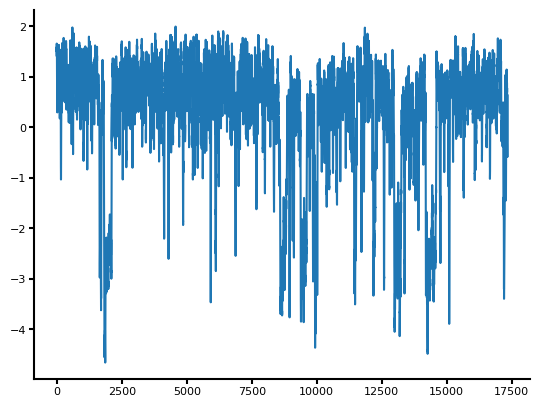

In [56]:
plt.plot(Z[0])

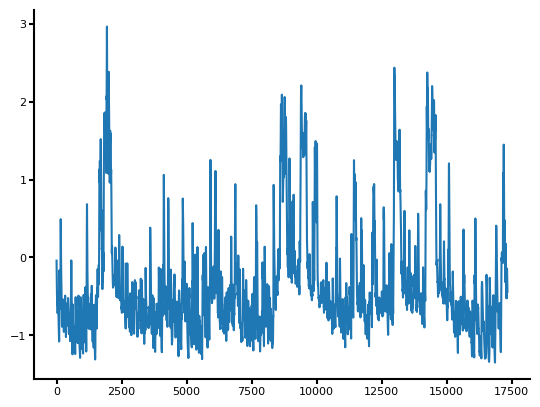

In [57]:
plt.plot(S.flatten())

Text(0.5, 1.0, 'Bifurcation Diagram')

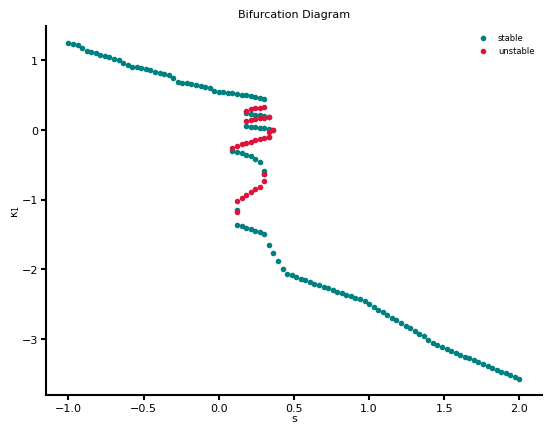

In [58]:
fig, ax = plt.subplots()
stable = np.array(stable)
unstable = np.array(unstable)

# ax.scatter(stable[:, 3], stable[:, 2], label='stable', c='teal')
# ax.scatter(unstable[:, 3], unstable[:, 2], label='unstable', c='crimson')

ax.scatter(stable[:, 1], stable[:, 0], label='stable', c='teal')
ax.scatter(unstable[:, 1], unstable[:, 0], label='unstable', c='crimson')

ax.set_xlabel('s')
ax.set_ylabel(r'$\kappa_1$')
# ax.set_xticks(np.arange(0, 1, 0.3))
# ax.set_xticklabels(f'{s_vals[i]:.2f}' for i in range(0, len(s_vals), 15)) 
# ax.axvline(s_test_baseline.mean(), linestyle='--', alpha=0.5)
# ax.axvline(s_test_baseline.mean() + s_test_baseline.std(), linestyle='--', alpha=0.5)
ymin, ymax = ax.get_ylim()
# ax.text(s_test_baseline.mean(), ymax * 0.9, 'Baseline Mean', rotation=90, color='black', va='top', ha='right')
# ax.text(s_test_baseline.mean() + s_test_baseline.std(), ymax * 0.9, '1 stdev', rotation=90, color='black', va='top', ha='right')
# ax.set_xticks([0, np.round(s_test_baseline.mean(), 1), s_test_baseline.mean() + s_test_baseline.std(), 0.25])
ax.legend()
# ax.xaxis.set_major_formatter(FormatStr/Formatter('%.2f'))
# ax.set_xlim([0, 0.5])
plt.title('Bifurcation Diagram')
# fig.savefig('../results/figures/nk339_bifurcations_postsynaptic_1.svg', format='svg')

In [59]:
def get_generator_F(kappas, s, tau, U, V, A, B, neuromodulation='postsynaptic'): 
    def relu(x):
        if type(x) == torch.tensor:
            return torch.clamp(x, 0.0)
        return np.maximum(x, 0)
    
    if neuromodulation == 'postsynaptic':
        R = relu(kappas @ U.T + B.reshape(1, -1)) - relu(kappas @ U.T) # batch x dx
        W = 1.0 + s * A.flatten()
        kappa_t = (tau) * kappas + (V @ (W.reshape(1, -1) * R).T).T
    elif neuromodulation == 'additive': 
        W = s * A
        R  = relu(kappas @ U.T + W.T + B.reshape(1, -1)) - relu(kappas @ U.T + W.T)
        # print(R.shape)
        kappa_t = (tau) * kappas + (V @ R.T).T
        
    h = .1
    dk = (kappa_t - kappas)/h
    return dk

In [60]:
class MeanField(nn.Module):
    """
    Clipped Relu Mean field model
    """
    def __init__(self, P=2, tau=0.9252, sigma_mm_floor=5e-2, beta_init=0.6,
                 sigma_n_alpha_signs=None, neuromodulation='postsynaptic'):
        super().__init__()
        self.P = int(P)
        self.sigma_mm_floor = float(sigma_mm_floor)
        self.eps = 1e-6

        if sigma_n_alpha_signs is None:
            signs = torch.tensor([1 if i % 2 == 0 else -1 for i in range(self.P)], dtype=torch.float32)
        else:
            signs = sigma_n_alpha_signs.to(torch.float32).flatten()
            assert signs.numel() == self.P
        self.register_buffer("sign_sigma_n_alpha", signs.view(self.P, 1))

        self.raw_sigma_n_alpha = nn.Parameter(torch.randn(self.P, 1))  
        self.sigma_n_m = nn.Parameter(torch.randn([self.P, 1]))
        self.sigma_m_alpha = nn.Parameter(torch.randn(self.P, 1)) 
        self.sigma_m_m = nn.Parameter(torch.randn(self.P, 1)) 
        self.beta = nn.Parameter(torch.full((self.P, 1), float(beta_init)))
        # self.mu = nn.Parameter(torch.zeros(self.P, 1))   

        self.raw_tau = nn.Parameter(torch.tensor(0.9))   
        self.s_gain = nn.Parameter(torch.tensor(1.0), requires_grad=False)
        self.s_bias = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.neuromodulation = neuromodulation 

        # constants
        self.register_buffer("inv_sqrt_2pi", torch.tensor(1.0 / math.sqrt(2*math.pi)))
        self.register_buffer("inv_sqrt_2",   torch.tensor(1.0 / math.sqrt(2.0)))


    def tau(self): return torch.tensor(0.9252)
    def sigma_mm_pos(self): return self.sigma_mm_floor + F.softplus(self.raw_sigma_m_m)
    @staticmethod
    def abs_smooth(x, eps=1e-6): return torch.sqrt(x*x + eps*eps)
    def delta(self, k, s=None): 
        if self.neuromodulation == 'additive':
            return torch.sqrt(self.sigma_m_m**2 * k.unsqueeze(1)**2 + 1e-4 + self.sigma_m_alpha**2 * s.unsqueeze(1)**2)
        return torch.sqrt(self.sigma_m_m**2 * k.unsqueeze(1)**2 + 1e-4) 

    def _pdf(self,z): return self.inv_sqrt_2pi * torch.exp(-0.5*z*z)
    def _cdf(self,z): return 0.5 * (1.0 + torch.erf(z * self.inv_sqrt_2))


    def E_mean(self, delta, beta):
        a = torch.clamp(beta/delta, -12, 12)
        return delta*(self._pdf(a)-self.inv_sqrt_2pi) + beta*self._cdf(a)

    def E_gain(self, delta, beta):
        a = torch.clamp(beta/delta, -12, 12)
        return self._cdf(a) - 0.5

    def E_curv(self, delta, beta):
        a = torch.clamp(beta/delta, -12, 12)
        return (self.inv_sqrt_2pi/delta) * (torch.exp(-0.5*a*a) - 1.0)

    def sigma_n_alpha(self):
        return self.raw_sigma_n_alpha
        # return self.sign_sigma_n_alpha * F.softplus(self.raw_sigma_n_alpha)

    def step(self, k, s_t, noise=0.0):
        """
        k:   (B,1)
        s_t: (B,1)
        ->   (B,1)
        """
        B = k.size(0)
        delta = self.delta(k, s_t)                         
        beta = self.beta                             

        mean = self.E_mean(delta, beta).view(B, self.P)
        gain = self.E_gain(delta, beta).view(B, self.P)
        curv = self.E_curv(delta, beta).view(B, self.P)

        if self.neuromodulation == 'additive': 
            k_rec = (k * gain * self.sigma_n_m.view(1, self.P)).sum(1) + (s_t * gain * self.sigma_n_alpha().view(1, self.P)).sum(1)
            J_lin = torch.tensor([])
        else: 
            s_eff = self.s_gain * (s_t - self.s_bias)     
            sB = s_eff.expand(B, self.P)

            J_lin  = (self.sigma_n_m.view(1, self.P) * gain).sum(1)                     
            bias   = (sB * (self.sigma_n_alpha().view(1, self.P) * mean)).sum(1)        
            curv_g = (sB * (self.sigma_n_m.view(1, self.P) *
                            self.sigma_m_alpha.view(1, self.P) * curv)).sum(1)          

            k_rec  = k.view(B)*J_lin + bias + (k.view(B)**2)*curv_g
        k_next = (1 - self.tau())*k.view(B) + self.tau()*k_rec + noise
        return k_next.unsqueeze(1), J_lin                                                  

    def rollout_batch(self, s_seq: torch.Tensor, k0: torch.Tensor, noise_std=0.0):
        """
        s_seq: (B, T) or (T,)
        k0:    (B, 1)
        returns: (B, T), J_lins 
        """
        if s_seq.dim() == 1:               
            B = k0.size(0)
            s_seq = s_seq.view(1, -1).expand(B, -1)   
        elif s_seq.dim() == 2:           
            B = s_seq.size(0)
 
        T = s_seq.size(1)
        k = k0
        outs, J_lins = [], []
        for t in range(T):
            noise = torch.randn(B) * noise_std
            k, J_lin = self.step(k, s_seq[:, t:t+1], noise=noise.to(k.device))  
            outs.append(k)
            J_lins.append(J_lin)
        return torch.cat(outs, dim=1), torch.cat(J_lins)  

    
    def kappa_rec(self, k, s_t):
        B = k.size(0)
        delta = self.delta(k, s_t)               
        beta = self.beta

        mean = self.E_mean(delta, beta).view(B, self.P)
        gain = self.E_gain(delta, beta).view(B, self.P)
        curv = self.E_curv(delta, beta).view(B, self.P)

        if self.neuromodulation == 'additive': 
            return (k * gain * self.sigma_n_m.view(1, self.P)).sum(1) + (s_t * gain * self.sigma_n_alpha().view(1, self.P)).sum(1)
            
        s_eff = self.s_gain * (s_t - self.s_bias)   
        sB = s_eff.expand(B, self.P)

        J_lin  = (self.sigma_n_m.view(1,self.P) * gain).sum(1)                       
        bias   = (self.sigma_n_alpha().view(1,self.P) * mean).sum(1)                 
        curv_g = (self.sigma_n_m.view(1,self.P) * self.sigma_m_alpha.view(1,self.P) * curv).sum(1)

        κ = k.view(B)
        return κ*J_lin + s_eff.view(B)*bias + (κ**2)*s_eff.view(B)*curv_g

    def F(self, k, s_t):
        κrec = self.kappa_rec(k, s_t)
        return κrec - k.view(-1)



In [61]:
def fp_loss(model, s_vals, fixed_points, stab_signs,
            bifurcation_points, sn_points=[], lambda_fp=3.0, lambda_stab=0.0, 
            lambda_bifurc=0.3, lamF=5e-2, lamJ=5e-2, lamH=1e-1, kappa_min=-3, kappa_max=1, eps=1e-3, gaussian_weights=None):
    device = next(model.parameters()).device
    dtype  = next(model.parameters()).dtype

    weights = torch.ones(len(s_vals), device=device, dtype=dtype)

    total_fp = torch.tensor(0., device=device, dtype=dtype)
    total_manifold = torch.tensor(0., device=device, dtype=dtype)
    total_stab = torch.tensor(0., device=device, dtype=dtype)
    L_sn = torch.tensor(0., device=device, dtype=dtype)
    w_sum_fp = torch.tensor(0., device=device, dtype=dtype)
    w_sum_stab = torch.tensor(0., device=device, dtype=dtype)

    for i, s_i in enumerate(s_vals):
        # skip if no targets at this s
        if len(fixed_points[i]) == 0:
            continue

        s_i_t = torch.tensor([[float(s_i)]], device=device, dtype=dtype)

        ks = torch.tensor(fixed_points[i], device=device, dtype=dtype).view(-1, 1)
        fp_mask = torch.tensor(stab_signs[i], device=device) < 0
        fp_mask = fp_mask.flatten()
        fp_mask.requires_grad_(False) 
        
        w = weights[i] 
        ks.requires_grad_(True)

        # F(κ*, s)
        F_vals = model.F(ks, s_i_t.expand_as(ks))  
        # fixed-point residual 
        L_fp_i = (F_vals**2).sum()
        total_fp = total_fp + w * L_fp_i
        w_sum_fp = w_sum_fp + w

        # randomly sample n points from generator 
        rand_points = np.linspace(kappa_min, kappa_max, 40) 
        F_vals_generator = get_generator_F(rand_points.reshape(-1, 1), s_i_t.cpu().numpy(), 0.92, U, V, A, B)
        rand_points = torch.from_numpy(rand_points).to(device).reshape(-1, 1)
        rand_points.requires_grad = False 

        F_vals_mf = model.F(rand_points, s_i_t.expand_as(rand_points))
        total_manifold += F.mse_loss(F_vals_mf.flatten(), torch.from_numpy(F_vals_generator).to(device).flatten()) 

    if w_sum_fp.item() > 0:
        L_fp = lambda_fp * total_fp / w_sum_fp
    else:
        L_fp = torch.tensor(0., device=device, dtype=dtype)

    if w_sum_stab.item() > 0:
        L_stab = lambda_stab * (total_stab / w_sum_stab)
    else:
        L_stab = torch.tensor(0., device=device, dtype=dtype)

    L_manifold = lambda_bifurc * total_manifold
    return L_fp, L_stab, L_manifold


In [62]:
def saddle_node_loss(
    model,
    s0: float,
    s1: float,
    kappa_fold: float,
    kappa_fold_2: float,
    d_s: float = 0.05,
    eps_k: float = 1e-3,
    margin: float = 1e-2,
    device: str = "cuda:0"
):
    """
    Loss to enforce a saddle-node bifurcation at s0 
    """
    k_fold = torch.tensor([[kappa_fold]], device=device, dtype=torch.float32, requires_grad=True)
    k_fold_2 = torch.tensor([[kappa_fold_2]], device=device, dtype=torch.float32, requires_grad=True)

    s_fold = torch.tensor([[s0]], device=device, dtype=torch.float32)
    s_fold_2 = torch.tensor([[s1]], device=device, dtype=torch.float32)

    # Fold conditions at (kappa_fold, s0)
    F_fold = model.F(k_fold, s_fold)
    F_plus = model.F(k_fold + eps_k, s_fold)
    F_minus = model.F(k_fold - eps_k, s_fold)
    dF_dk = (F_plus - F_minus) / (2*eps_k)

    L_fold = F_fold.pow(2) + dF_dk.pow(2) 
       

    F_fold_2 = model.F(k_fold_2, s_fold_2)
    F_plus_2 = model.F(k_fold_2 + eps_k, s_fold_2)
    F_minus_2 = model.F(k_fold_2 - eps_k, s_fold_2)
    dF_dk_2 = (F_plus_2 - F_minus_2) / (2*eps_k)

    L_fold_2 = F_fold_2.pow(2) + dF_dk_2.pow(2) 
    
    # total
    L_total = L_fold + L_fold_2  
    return L_total


In [78]:
def train_meanfield(model, Z, s, iters_1=1500, iters_2=600, batch_1=2048, win_2=50, batch_2=128, lr_start=0.001, lr_end=0.001, lambda_mse=2.5, lambda_bifurc=20.0, device='cuda:0', gaussian_weights=None):
    opt = torch.optim.Adam(model.parameters(), lr=lr_start)
    gamma = (lr_end / lr_start) ** (1 / iters_2)
    print(f'gamma = {gamma}')
    scheduler = optim.lr_scheduler.ExponentialLR(opt, gamma)
    T = Z.numel()

    for it in range(iters_1):
        opt.zero_grad()
        idx = torch.randint(0, T-1, (batch_1,))
        k = Z[idx].view(-1,1)
        sb = s[idx].view(-1,1)
        target = Z[idx+1]
        pred, J_lin = model.step(k, sb)
        eps = 0.05
        jlin_pen = 0
        loss = F.mse_loss(pred.flatten(), target) 

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if it % 200 == 0:
            print(f"[one-step {it}] loss={loss.item():.5f}, tau={model.tau().item():.3f}")


    loss_final = 0.0
    for it in range(iters_2):
        opt.zero_grad()

        # sample a batch of starting indices for windows
        st = torch.randint(0, T - (win_2+1), (batch_2,))               
        offsets = torch.arange(win_2+1)                                  
        idx_mat = st.unsqueeze(1) + offsets.unsqueeze(0)                

        # gather windows
        Zw = Z[idx_mat]                                                  
        sw = s[idx_mat]                                                  

        # model rollout over the batch
        pred, _ = model.rollout_batch(sw[:, 1:], Zw[:, 0:1])             

        # compute fixed point loss
        L_fp_batch, L_stab_batch, L_manifold = fp_loss(
            model,
            s_vals,
            fixed_points,
            stab_signs=eig_vals,
            bifurcation_points=bifurcation_points,
            sn_points=None,
            gaussian_weights=gaussian_weights
        )
        # L_saddle_node = saddle_node_loss(
        #                     model,
        #                     s_vals[bifurcation_points[0]],
        #                     s_vals[bifurcation_points[-2]],
        #                     kappa_fold=0.0,
        #                     kappa_fold_2=fixed_points[bifurcation_points[-1]],
        #                 )

        L_fp = L_fp_batch
        L_stab = L_stab_batch
        
        L_mse = lambda_mse * F.mse_loss(pred, Zw[:, 1:])
        loss = L_fp +  L_manifold + L_mse #+ L_saddle_node 
        loss.backward()
        # nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        
        print(f"[rollout  {it}] loss={loss.item():.2f}, L_mse: {L_mse}, L_fp: {L_fp}, L_manifold: {L_manifold}, lr: {scheduler.get_last_lr()}")
        
        scheduler.step()
        loss_final = loss.item()
    
    return model, loss_final


In [79]:
torch.manual_seed(1)
np.random.seed(1)

gamma = 1.0
[one-step 0] loss=1.38157, tau=0.925
[one-step 200] loss=0.37011, tau=0.925
[one-step 400] loss=0.08643, tau=0.925
[one-step 600] loss=0.06401, tau=0.925
[one-step 800] loss=0.05558, tau=0.925
[rollout  0] loss=5.85, L_mse: 1.5919910669326782, L_fp: 0.15049465000629425, L_manifold: 4.112088203430176, lr: [0.001]
[rollout  1] loss=5.66, L_mse: 1.553332805633545, L_fp: 0.14049218595027924, L_manifold: 3.963913679122925, lr: [0.001]
[rollout  2] loss=5.97, L_mse: 1.9744856357574463, L_fp: 0.13750070333480835, L_manifold: 3.8603932857513428, lr: [0.001]
[rollout  3] loss=5.65, L_mse: 1.7580580711364746, L_fp: 0.1287635713815689, L_manifold: 3.766718864440918, lr: [0.001]
[rollout  4] loss=5.52, L_mse: 1.702559232711792, L_fp: 0.12905339896678925, L_manifold: 3.683389186859131, lr: [0.001]
[rollout  5] loss=5.21, L_mse: 1.542340636253357, L_fp: 0.12088094651699066, L_manifold: 3.550588369369507, lr: [0.001]
[rollout  6] loss=5.35, L_mse: 1.8042354583740234, L_fp: 0.1156703308224

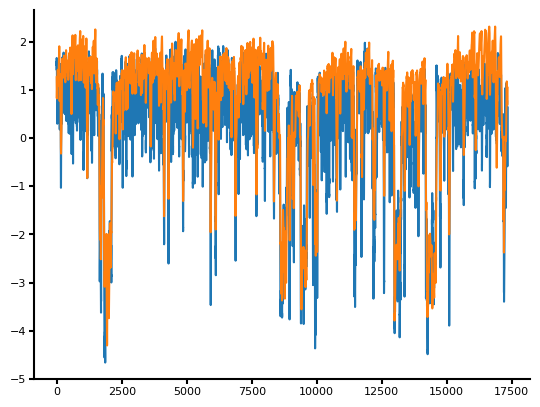

In [80]:
device='cuda:0'

Z = Z.flatten().to(device)
s = S.flatten().to(device)
s = s.flatten().to(device)

mean_field_model = MeanField(P=2, sigma_n_alpha_signs=None).to(torch.float32).to(device)
mean_field_model, loss = train_meanfield(mean_field_model, Z, s=s, iters_1=1000, iters_2=50, lr_start=0.001, lr_end=0.001, gaussian_weights=None)

with torch.no_grad():
    pred, J_lin = mean_field_model.rollout_batch(S.flatten()[1:].to(device), Z[0:1].to(device))
    pred = pred.flatten()
    mse = F.mse_loss(pred, Z[1:]).item()
    r2 = r2_score(Z[1:].cpu().numpy(), pred.cpu().numpy())
    print(f'mse: {mse}, R2: {r2}')   
    # torch.save(mean_field_model.state_dict(), f"../models/mean field/nk339_mPFC_postsynaptic_seed_11_{mean_field_model.P}_populations_mean_field_seed_{i}.pth")
    plt.plot(Z[1:].cpu().numpy())
    plt.plot(pred.cpu().numpy())


In [27]:
# device = 'cpu'
# mean_field_model = MeanField(P=2).to(device)
# mean_field_model.load_state_dict(torch.load(f"../models/all/nk339_mPFC_postsynaptic_seed_0_{mean_field_model.P}_populations_mean_field_final_bifurc.pth", map_location=torch.device('cpu')))


/tmp/ipykernel_1279345/1472160314.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mean_field_model.load_state_dict(torch.load(f"../models/all/nk339_mPFC_postsynaptic_see

<All keys matched successfully>

In [81]:
print("sigma_n_alpha =", mean_field_model.sigma_n_alpha().view(-1).tolist())
print("sigma_n_m     =", mean_field_model.sigma_n_m.view(-1).tolist())
print("sigma_m_alpha =", mean_field_model.sigma_m_alpha.view(-1).tolist())
print("sigma_m_m     =", mean_field_model.sigma_m_m.view(-1).tolist())
print("beta          =", mean_field_model.beta.view(-1).tolist())
print("s affine      =", {"gain": mean_field_model.s_gain.item(), "bias": mean_field_model.s_bias.item()})

sigma_n_alpha = [0.274184912443161, -0.19230987131595612] (pop1>0, pop2<0)
sigma_n_m     = [0.6448080539703369, 1.1939932107925415]
sigma_m_alpha = [0.6307781934738159, 0.029655439779162407]
sigma_m_m     = [-0.3120371401309967, 0.11380107700824738]
beta          = [0.33446773886680603, 0.8595137596130371]
s affine      = {'gain': 1.0, 'bias': 0.0}


### Test similarity between mean field model and generator

### Build the covariance matrices for the two populations

In [58]:
cov1 = [
    [2.75, mean_field_model.sigma_n_m.flatten()[0].item(), mean_field_model.sigma_n_alpha().flatten()[0].item()],
    [mean_field_model.sigma_n_m.flatten()[0].item(), F.softplus(mean_field_model.sigma_m_m.flatten()[0]).item(), mean_field_model.sigma_m_alpha.flatten()[0].item()],
    [mean_field_model.sigma_n_alpha().flatten()[0].item(), mean_field_model.sigma_m_alpha.flatten()[0].item(), 0.84]
]

cov2 = [
    [1.45, mean_field_model.sigma_n_m.flatten()[1].item(), mean_field_model.sigma_n_alpha().flatten()[1].item()],
    [mean_field_model.sigma_n_m.flatten()[1].item(), F.softplus(mean_field_model.sigma_m_m.flatten()[1]).item(), mean_field_model.sigma_m_alpha.flatten()[1].item()],
    [mean_field_model.sigma_n_alpha().flatten()[1].item(), mean_field_model.sigma_m_alpha.flatten()[1].item(), 0.98]
]

In [59]:
B1 = torch.linalg.cholesky(torch.tensor(cov1))
B2 = torch.linalg.cholesky(torch.tensor(cov2))

_LinAlgError: linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 3 is not positive-definite).

In [ ]:
device = 'cpu'
mean_field_model = mean_field_model.to(device)

In [27]:
def relu(x): return torch.clamp(x, 0.0)
def clipped_relu(h, b): return relu(h + b) - relu(h)
def clipped_relu_derivative(h, b):
    return ((h + b) > 0.0).to(h.dtype) - (h > 0.0).to(h.dtype)  # 1 on (-b,0), else 0

def sample_from_cov(S, N):
    L = torch.linalg.cholesky(S + 1e-8*torch.eye(3, device=S.device))
    X = torch.randn(N, 3, device=S.device) @ L.T
    return X[:,0].clone(), X[:,1].clone(), X[:,2].clone()

In [46]:
def net_rollout(T: int, s_raw: np.ndarray, m, n, b_corr, alpha, s_gain_new = 1.0, tau=0.9252, kappa_0 = 0.0):
    N = m.shape[0]
    s_eff = s_gain_new * (s_raw - mean_field_model.s_bias.item())
    h = torch.zeros(N)
    ks = np.zeros(T, dtype=float)
    hs = np.zeros((N, T))
    ks[0] = kappa_0 
    h = kappa_0 * m 
    hs[:, 0] = h

    for t in range(T):
        phi = clipped_relu(h, b_corr)                     
        y   = (1.0 + s_eff[t] * alpha) * phi
        zn  = float((n * y).mean().item())
        h   = (1 - tau) * h + tau * (m * zn)
        ks[t]= float((n * phi).mean().item())
    return ks, hs

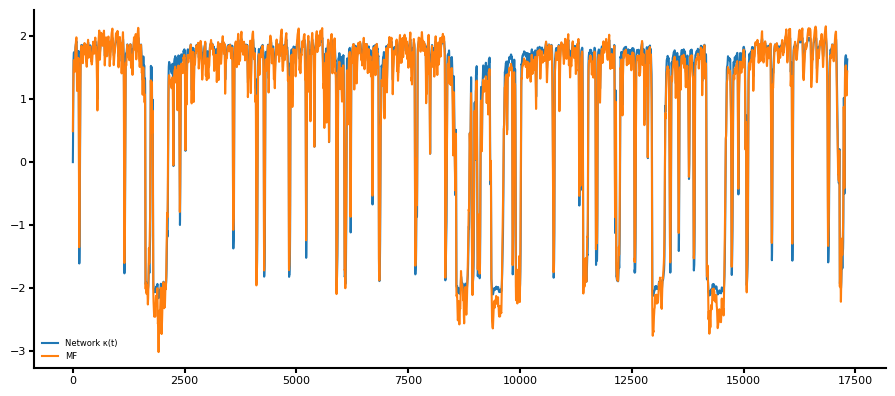

In [214]:
N1 = N2 = 2500
tau = 0.9252
P = 2
pi = torch.tensor([1.0, 1.0], dtype=torch.float32)

S1 = torch.tensor(cov1, dtype=torch.float32, device=device)
S2 = torch.tensor(cov2, dtype=torch.float32, device=device)

n1, m1, a1 = sample_from_cov(S1, N1)
n2, m2, a2 = sample_from_cov(S2, N2)
n = torch.cat([n1, n2]); m = torch.cat([m1, m2]); alpha = torch.cat([a1, a2])
n -= n.mean(); m -= m.mean(); alpha -= alpha.mean()
N = n.numel()

beta = mean_field_model.beta.detach().flatten()
mu   = mean_field_model.mu.detach().flatten()
b = torch.cat([(beta[0] + mu[0]).expand(N1),
               (beta[1] + mu[1]).expand(N2)]).to(device)

with torch.no_grad():
    k0 = torch.zeros(1,1, device=device)
    Delta0 = mean_field_model.delta(k0) 
    Eg0 = mean_field_model.E_gain(Delta0, mean_field_model.beta).view(-1)  
    J_target = float((pi * mean_field_model.sigma_n_m.view(-1) * Eg0).sum().item())

Eg0_per_neuron = torch.cat([Eg0[0].expand(N1), Eg0[1].expand(N2)]).to(device)
J_net = float((n * m * Eg0_per_neuron).mean().item())

m *= (J_target / (J_net + 1e-12)) 

h_alpha = 0.8
s_gain_new = 1.0

alpha *= h_alpha

b_corr = torch.cat([
    (mean_field_model.beta[0,0] + mean_field_model.mu[0,0] + 5.0).expand(N1),
    (mean_field_model.beta[1,0] + mean_field_model.mu[1,0] + 5.0).expand(N2)
]).to(device)


s = S.numpy().flatten()
T = s.shape[0]    
k_net = net_rollout(T, s, m, n, b_corr, alpha)

plt.figure(figsize=(9,4))
plt.plot(k_net, label="Network κ(t)")
plt.plot(pred.flatten().cpu().numpy(), label="MF")
plt.legend(); plt.tight_layout(); plt.show()




In [82]:
def plot_Fprime_heatmap(model,
                        model_type,
                        s_min=0.0, s_max=1.0,
                        k_min=-7.0, k_max=2.0,
                        Ns=200, Nk=200,
                        filename=None,
                        vlim=None,
                        fixed_points=None,
                        device='cuda:0'
                        ):

    # device = next(model.parameters()).device
    dtype  = next(model.parameters()).dtype
    model.eval()

    # grid
    s_lin = torch.linspace(s_min, s_max, Ns, device=device, dtype=dtype)
    k_lin = torch.linspace(k_min, k_max, Nk, device=device, dtype=dtype)

    Fprime = torch.empty(Ns, Nk, device=device, dtype=dtype)

    for i, s_i in enumerate(s_lin):
        k_batch = k_lin.view(-1, 1).clone().detach().to(device)  # (Nk,1)
        s_batch = s_i.repeat(Nk).view(-1, 1)                                 # (Nk,1)

        if model_type == 'mean_field':
            F_vals = model.F(k_batch, s_batch)                                       # (Nk,)
        elif model_type == 'generator':
            # F_vals, _, _ = model.rnn(k_batch.to(device).view(-1, 1, 1, 1), s_batch.to(device).view(-1, 1, 1, 1))  
            # F_vals = (F_vals.flatten() - k_batch.flatten() ) / 0.5
            k_batch = k_batch.cpu()
            F_vals = get_generator_F(k_batch.numpy(), s_i.item(), 0.925, U, V, A, B, neuromodulation=model_config['neuromodulation'])
            F_vals = torch.from_numpy(F_vals).to(device)
        elif model_type == 'sampled': 
            k_batch = k_batch.cpu()
            F_vals = get_generator_F(k_batch.numpy(), s_i.item(), 0.925, m.reshape(-1, 1), n.reshape(1, -1), alpha.reshape(-1, 1), b_corr)
            F_vals = torch.from_numpy(F_vals).to(device)
            # print(F_vals.shape)
        # (grad_k,) = torch.autograd.grad(F_vals.sum(), k_batch,
        #                                 retain_graph=False, create_graph=False)
        Fprime[i] = F_vals.flatten()

    Fp_np = Fprime.detach().cpu().numpy()

    # plotting with diverging colormap
    plt.figure(figsize=(7,4))
    extent = [s_min, s_max, k_min, k_max]
    if vlim is None:
        vmax = np.max(np.abs(Fp_np))
    else:
        vmax = vlim
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = plt.imshow(Fp_np.T, origin='lower', extent=extent, aspect='auto',
                    cmap='bwr', norm=norm)
    plt.colorbar(im, label=r"$F(\kappa,s)$")
    plt.xlabel("s")
    plt.ylabel(r"$\kappa$")
    plt.title(r"Field $F(\kappa,s)$")

    # overlay fixed points if provided
    if fixed_points is not None:
        fixed_points = np.array(fixed_points, dtype=float)
        if fixed_points.shape[1] == 2:
            s_fp, k_fp = fixed_points[:,0], fixed_points[:,1]
            plt.scatter(s_fp, k_fp, c='k', s=20, marker='o', label="fixed points")
        elif fixed_points.shape[1] == 3:
            for s_fp, k_fp, stable in fixed_points:
                if stable:
                    plt.scatter(s_fp, k_fp, c='k', s=20, marker='o')  # stable = filled circle
                else:
                    plt.scatter(s_fp, k_fp, c='k', s=20, marker='x')  # unstable = x
        plt.legend()

    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, format='svg')
    plt.show()


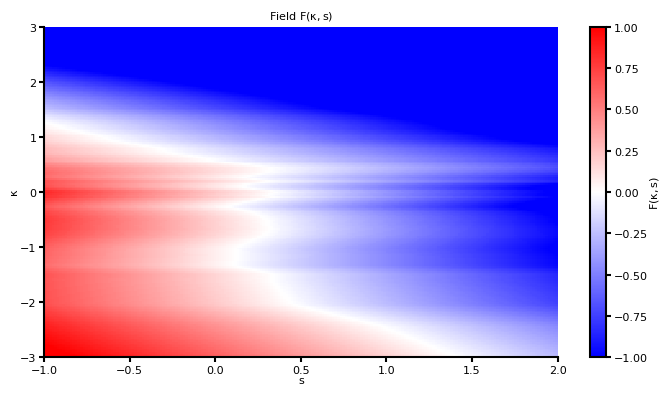

In [83]:
plot_Fprime_heatmap(model.to('cpu'),
                        model_type='generator',
                        fixed_points=None,
                        s_min=-1.0, s_max=2.0,
                        k_min=-3.0, k_max=3.0,
                        Ns=200, Nk=200,
                        vlim=1.0,
                        filename=None,
                        device='cpu')

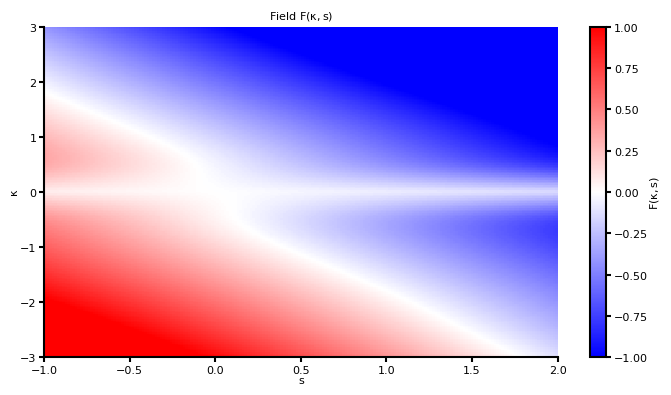

In [84]:
plot_Fprime_heatmap(mean_field_model.to('cpu'),
                        model_type='mean_field',
                        fixed_points=None,
                        s_min=-1.0, s_max=2.0,
                        k_min=-3.0, k_max=3.0,
                        Ns=200, Nk=200,
                        vlim=1.0,
                        filename='mean_field_F.svg',
                        device='cpu')

### Study the mean rate and curvature factors as a function of $\kappa$ and $s$

In [85]:
mean_field_model = mean_field_model.to(device)

In [43]:
means, gains, curvs = [], [], []
P = mean_field_model.P
kappa_ = np.linspace(-3, 3, 50)
s_ = np.linspace(-3, 3, 50)
for k in kappa_:
    for s in s_:
        delta = mean_field_model.delta(torch.tensor([k], device=device))        
        
        pop_means = s * k * mean_field_model.sigma_n_alpha() * mean_field_model.E_mean(delta, mean_field_model.beta).view(P, -1)
        pop_gains =  mean_field_model.E_gain(delta, mean_field_model.beta).view(P, -1)
        pop_curvs = mean_field_model.E_curv(delta, mean_field_model.beta).view(P, -1)
        pop_curv_couplings = s * k ** 2 * mean_field_model.sigma_n_m * mean_field_model.sigma_m_alpha * pop_curvs

        pop_means = pop_means.flatten() 
        pop_gains = pop_gains.flatten() 
        pop_curv_couplings = pop_curv_couplings.flatten() 

        means.append([k, s, pop_means[0].item(), pop_means[1].item()])
        gains.append([k, s, pop_gains[0].item(), pop_gains[1].item()])
        curvs.append([k, s, pop_curv_couplings[0].item(), pop_curv_couplings[1].item()])


In [44]:
means = np.array(means)
gains = np.array(gains) 
curvs = np.array(curvs)

In [47]:
mean_field_model.sigma_n_alpha()

Parameter containing:
tensor([[0.0578],
        [0.2298]], requires_grad=True)

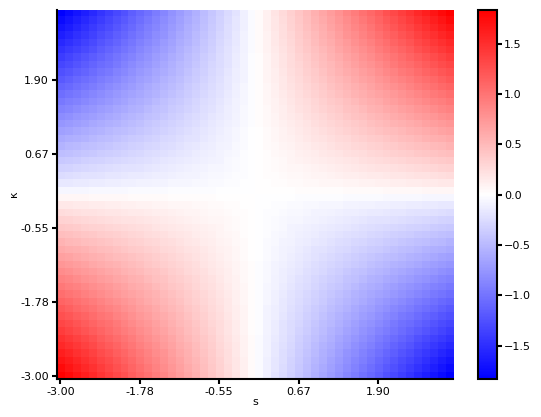

In [50]:
pop1_mean_rates = means[:, 2].reshape(50, 50)
plt.imshow(pop1_mean_rates, cmap='bwr', origin='lower', aspect='auto')
ticks = np.arange(0, 50, 10) 
plt.xticks(ticks, labels=[f'{s_[i]:.2f}' for i in ticks])
plt.yticks(ticks, labels=[f'{kappa_[i]:.2f}' for i in ticks])
plt.ylabel(rf'$\kappa$')
plt.xlabel('s')
plt.colorbar()

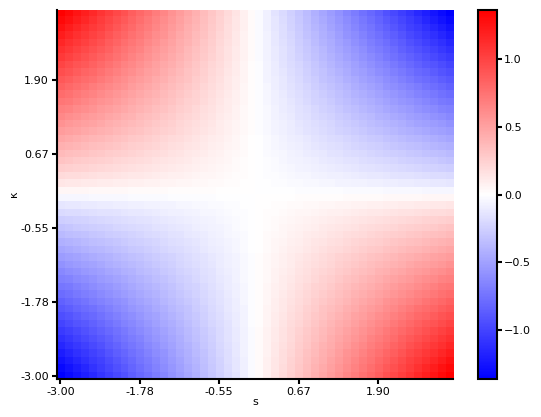

In [51]:
pop2_mean_rates = means[:, 3].reshape(50, 50)
plt.imshow(pop2_mean_rates, cmap='bwr', origin='lower', aspect='auto')
ticks = np.arange(0, 50, 10) 
plt.xticks(ticks, labels=[f'{s_[i]:.2f}' for i in ticks])
plt.yticks(ticks, labels=[f'{kappa_[i]:.2f}' for i in ticks])
plt.ylabel(rf'$\kappa$')
plt.xlabel('s')
plt.colorbar()

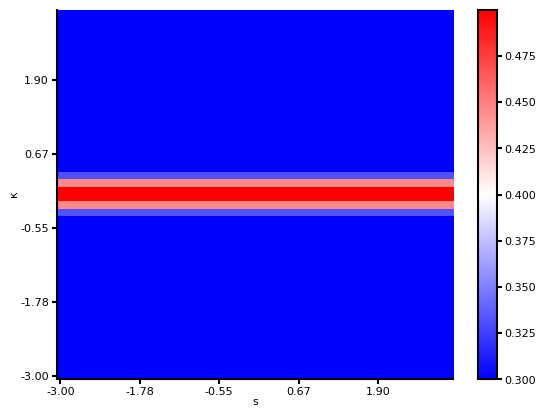

In [52]:
pop1_gains = gains[:, 2].reshape(50, 50)
plt.imshow(pop1_gains, cmap='bwr', origin='lower', aspect='auto', vmin=0.3)
ticks = np.arange(0, 50, 10) 
plt.xticks(ticks, labels=[f'{s_[i]:.2f}' for i in ticks])
plt.yticks(ticks, labels=[f'{kappa_[i]:.2f}' for i in ticks])
plt.ylabel(rf'$\kappa$')
plt.xlabel('s')
plt.colorbar()

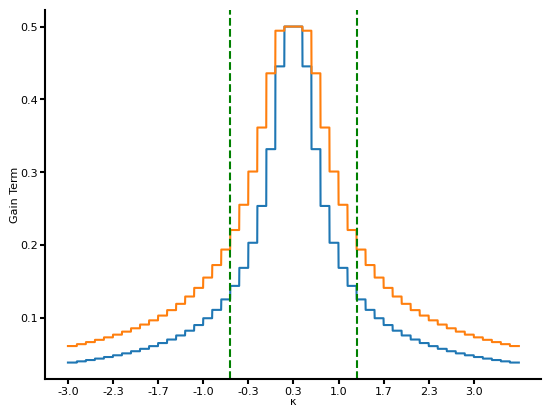

In [54]:
plt.plot(gains[:, 2], label='Pop 1 gain')
plt.plot(gains[:, 3], label='Pop 2 gain')
ticks = np.arange(0, 2500, 250)
k_vals_ticks = np.linspace(-3, 3, 10) 
plt.xticks(ticks, labels=[f'{k_vals_ticks[i] :.1f}' for i in range(len(k_vals_ticks))])
plt.xlabel(rf'$\kappa$')
plt.ylabel(rf"Gain Term")
plt.axvline(900, linestyle='--', color='green')
plt.axvline(1600, linestyle='--', color='green')

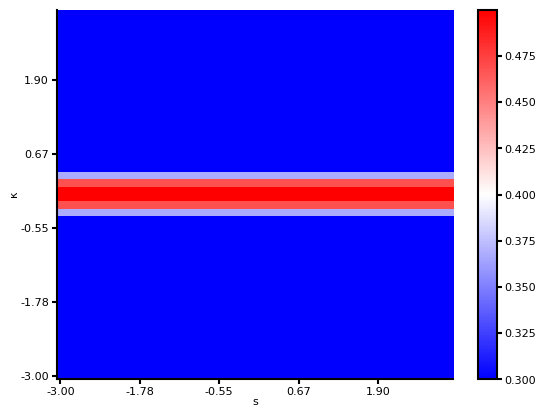

In [58]:
pop2_gains = gains[:, 3].reshape(50, 50)
plt.imshow(pop2_gains, cmap='bwr', origin='lower', aspect='auto', vmin=0.3)
ticks = np.arange(0, 50, 10) 
plt.xticks(ticks, labels=[f'{s_[i]:.2f}' for i in ticks])
plt.yticks(ticks, labels=[f'{kappa_[i]:.2f}' for i in ticks])
plt.ylabel(rf'$\kappa$')
plt.xlabel('s')
plt.colorbar()

In [60]:
mean_field_model.sigma_n_alpha()

tensor([[ 0.7260],
        [-0.8034]], device='cuda:0', grad_fn=<MulBackward0>)

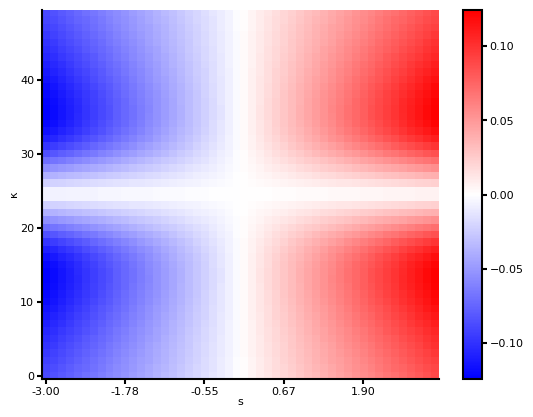

In [43]:
pop1_curvs = curvs[:, 2].reshape(50, 50)
plt.imshow(pop1_curvs, cmap='bwr', origin='lower', aspect='auto')
ticks = np.arange(0, 50, 10) 
plt.xticks(ticks, labels=[f'{s_[i]:.2f}' for i in ticks])
plt.ylabel(rf'$\kappa$')
plt.xlabel('s')
plt.colorbar()

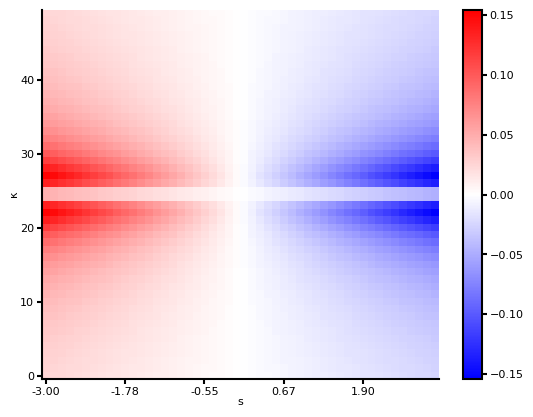

In [44]:
pop2_curvs = curvs[:, 3].reshape(50, 50)
plt.imshow(pop2_curvs, cmap='bwr', origin='lower', aspect='auto')
ticks = np.arange(0, 50, 10) 
plt.xticks(ticks, labels=[f'{s_[i]:.2f}' for i in ticks])
plt.ylabel(rf'$\kappa$')
plt.xlabel('s')
plt.colorbar()